# Logistic Regression

Data Set Information:

The data is related with direct marketing campaigns of a Portuguese banking institution. The marketing campaigns were based on phone calls. Often, more than one contact to the same client was required, in order to assess if the product (bank term deposit) would be subscribed.

In [64]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

# Data Exploration and Visualization

In [8]:
bank = pd.read_csv("https://github.com/fedhere/FDSfE_FBianco/raw/main/data/bank_term_deposit.csv")

In [9]:
bank.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,38,blue-collar,married,secondary,no,1663,yes,no,cellular,13,apr,217,3,327,1,failure,no
1,38,blue-collar,divorced,secondary,no,595,yes,no,cellular,7,may,245,3,-1,0,unknown,no
2,34,blue-collar,married,secondary,no,360,yes,no,telephone,19,nov,46,1,182,2,failure,no
3,60,admin.,married,secondary,no,1025,no,no,cellular,6,aug,388,8,-1,0,unknown,no
4,42,management,married,tertiary,no,520,no,no,cellular,4,nov,158,1,-1,0,unknown,no


In [11]:
bank.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1042 entries, 0 to 1041
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        1042 non-null   int64 
 1   job        1042 non-null   object
 2   marital    1042 non-null   object
 3   education  1042 non-null   object
 4   default    1042 non-null   object
 5   balance    1042 non-null   int64 
 6   housing    1042 non-null   object
 7   loan       1042 non-null   object
 8   contact    1042 non-null   object
 9   day        1042 non-null   int64 
 10  month      1042 non-null   object
 11  duration   1042 non-null   int64 
 12  campaign   1042 non-null   int64 
 13  pdays      1042 non-null   int64 
 14  previous   1042 non-null   int64 
 15  poutcome   1042 non-null   object
 16  y          1042 non-null   object
dtypes: int64(7), object(10)
memory usage: 138.5+ KB


In [12]:
bank["y"].unique()

array(['no', 'yes'], dtype=object)

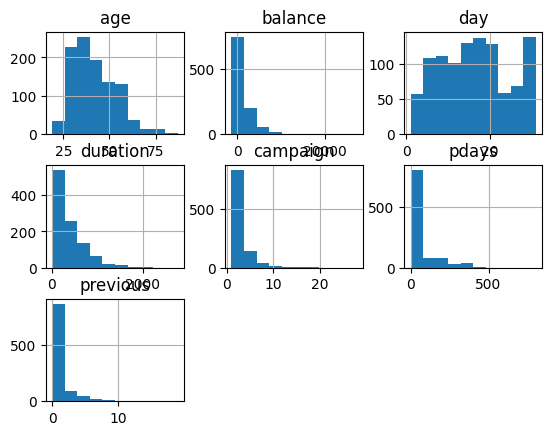

In [13]:
bank.hist();

In [17]:
bank["target"] = (bank["y"] == "yes").astype(int)

In [36]:
columns = ["age", "balance", "duration", "marital"]
features = bank[cols]
targets = bank["target"]

In [37]:
features

,age,balance,duration,marital
0,38,1663,217,married
1,38,595,245,divorced
2,34,360,46,married
3,60,1025,388,married
4,42,520,158,married
...,...,...,...,...
1037,26,668,576,single
1038,60,362,816,married
1039,42,1080,951,single
1040,32,620,1234,single


# One-Hot Encoding

In [38]:
features["marital"].unique()

array(['married', 'divorced', 'single'], dtype=object)

In [39]:
marital_features = pd.get_dummies(features["marital"], prefix="marital").astype(int)

In [40]:
features = features.join(marital_features).drop(columns="marital")

In [41]:
features

,age,balance,duration,marital_divorced,marital_married,marital_single
0,38,1663,217,0,1,0
1,38,595,245,1,0,0
2,34,360,46,0,1,0
3,60,1025,388,0,1,0
4,42,520,158,0,1,0
...,...,...,...,...,...,...
1037,26,668,576,0,0,1
1038,60,362,816,0,1,0
1039,42,1080,951,0,0,1
1040,32,620,1234,0,0,1


In [42]:
features.describe()

,age,balance,duration,marital_divorced,marital_married,marital_single
count,1042.000000,1042.000000,1042.000000,1042.000000,1042.000000,1042.000000
mean,41.706334,1435.856046,393.053743,0.130518,0.591171,0.278311
std,11.664298,2533.376586,350.984802,0.337034,0.491854,0.448383
min,19.000000,-1310.000000,8.000000,0.000000,0.000000,0.000000
25%,33.000000,95.000000,155.000000,0.000000,0.000000,0.000000
50%,40.000000,556.000000,275.000000,0.000000,1.000000,0.000000
75%,49.000000,1805.000000,526.000000,0.000000,1.000000,1.000000
max,87.000000,27359.000000,2769.000000,1.000000,1.000000,1.000000


# Min-Max Normalization

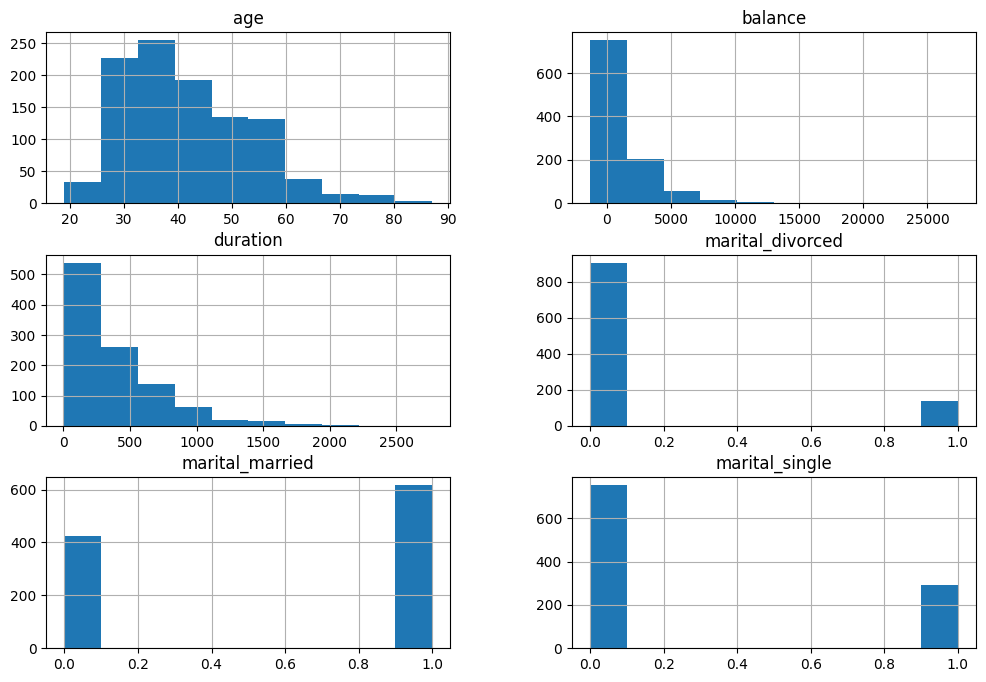

In [45]:
features.hist(figsize=(12, 8));

In [47]:
features.max() - features.min()

,0
age,68
balance,28669
duration,2761
marital_divorced,1
marital_married,1
marital_single,1


In [48]:
features = (features - features.min()) / (features.max() - features.min())

In [49]:
features.describe()

,age,balance,duration,marital_divorced,marital_married,marital_single
count,1042.000000,1042.000000,1042.000000,1042.000000,1042.000000,1042.000000
mean,0.333917,0.095778,0.139462,0.130518,0.591171,0.278311
std,0.171534,0.088366,0.127122,0.337034,0.491854,0.448383
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.205882,0.049008,0.053242,0.000000,0.000000,0.000000
50%,0.308824,0.065088,0.096704,0.000000,1.000000,0.000000
75%,0.441176,0.108654,0.187613,0.000000,1.000000,1.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


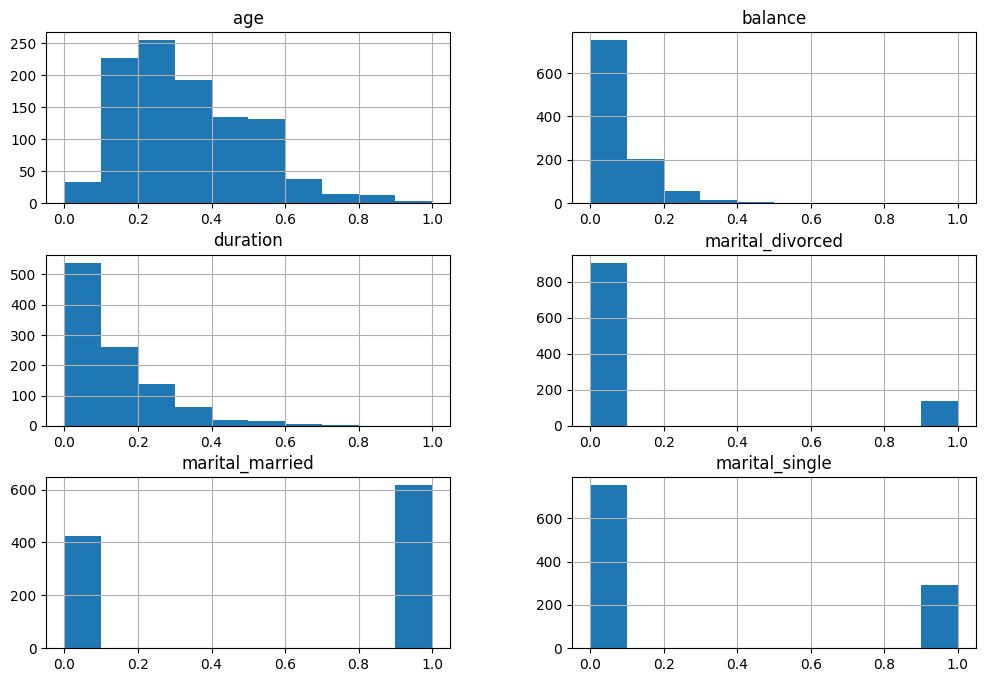

In [50]:
features.hist(figsize=(12, 8));

# Logistic Regression

In [52]:
logreg = LogisticRegression()
logreg.fit(features, targets)

LogisticRegression()

In [54]:
logreg.intercept_

array([-1.34980463])

In [55]:
logreg.coef_

array([[ 1.28349319,  0.87606627,  7.25975571,  0.02985416, -0.32687214,
         0.29408336]])

In [56]:
prediction = logreg.predict(features)

In [57]:
prediction

array([0, 0, 0, ..., 1, 1, 1])

In [59]:
(prediction == targets).sum() / len(targets)

np.float64(0.7236084452975048)

# Model Evaluation

In [62]:
print(classification_report(targets, prediction))

              precision    recall  f1-score   support

           0       0.69      0.82      0.75       521
           1       0.78      0.63      0.69       521

    accuracy                           0.72      1042
   macro avg       0.73      0.72      0.72      1042
weighted avg       0.73      0.72      0.72      1042



In [65]:
from sklearn.metrics import confusion_matrix

In [68]:
cm = confusion_matrix(targets, prediction)

Text(0.5, 1.0, 'Marketing Campaign Success Prediction')

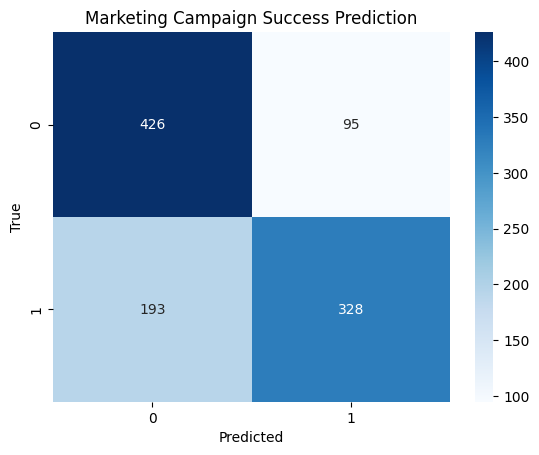

In [73]:
ax = sns.heatmap(cm, annot=True, cmap="Blues", fmt="d")
ax.set_ylabel("True")
ax.set_xlabel("Predicted")
ax.set_title("Marketing Campaign Success Prediction")